In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
import joblib

<Axes: >

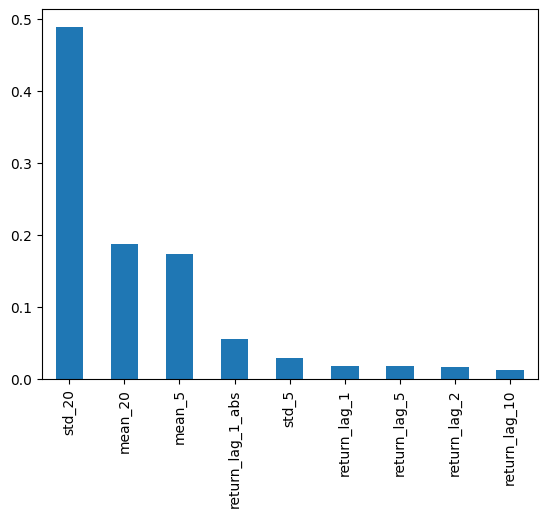

In [37]:
results = pd.read_csv("../results/predictions.csv", index_col=0, parse_dates=True)

with open("../results/metrics.json") as f:
    metrics = json.load(f)

with open("../results/feature_names.json") as f:
    feature_names = json.load(f)

ridge_regr = joblib.load("../results/ridge_model.pkl")
rf_regr = joblib.load("../results/rf_model.pkl")

type(ridge_regr), type(rf_regr)

In [23]:
results.head()

,actual,baseline_pred,ridge_pred,rf_pred
Date,,,,
2021-10-20,0.016855,0.010484,0.011836,0.013548
2021-10-21,0.015065,0.009879,0.010960,0.013764
2021-10-22,0.013815,0.011066,0.014756,0.013846
2021-10-25,0.014096,0.011237,0.014697,0.013891
2021-10-26,0.012970,0.010851,0.013297,0.013228


In [24]:
results.describe()

,actual,baseline_pred,ridge_pred,rf_pred
count,1051.000000,1051.000000,1051.000000,1051.000000
mean,0.020975,0.022065,0.021075,0.020626
std,0.010466,0.008134,0.005785,0.006281
min,0.004608,0.009879,0.010960,0.011051
25%,0.013537,0.015925,0.017121,0.016083
50%,0.018960,0.020764,0.019880,0.019251
75%,0.025850,0.025605,0.023842,0.023525
max,0.078698,0.057401,0.052668,0.080346


In [25]:
metrics

{'baseline_mae': 0.0075938961508146266,
 'baseline_mse': 0.0001074616328331668,
 'ridge_mae': 0.007007894485610421,
 'ridge_mse': 9.862465877331843e-05,
 'rf_mae': 0.006858875238623588,
 'rf_mse': 9.761080200623094e-05}

<Axes: xlabel='Date'>

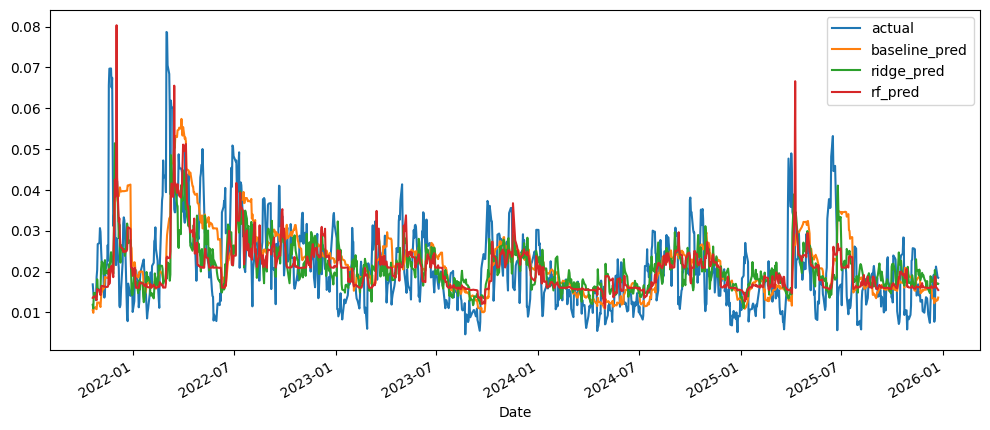

In [26]:
results[["actual", "baseline_pred", "ridge_pred", "rf_pred"]].plot(figsize=(12,5))

<Axes: xlabel='Date'>

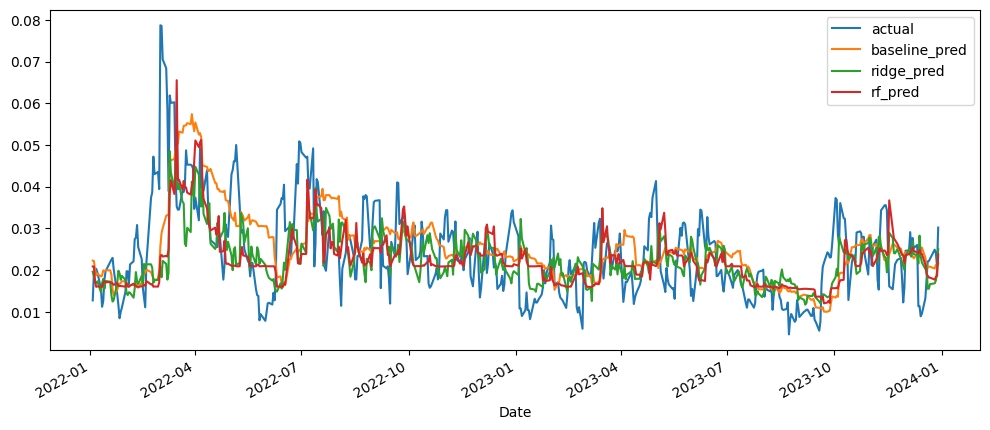

In [27]:
subset = results.loc["2022":"2023"]

subset[["actual", "baseline_pred", "ridge_pred", "rf_pred"]].plot(figsize=(12,5))

<Axes: xlabel='Date'>

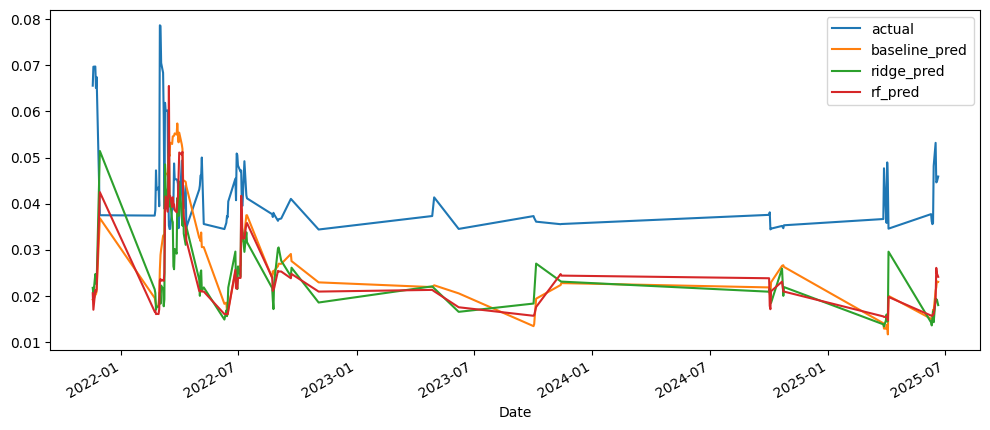

In [28]:
high_vol = results[results["actual"] > results["actual"].quantile(0.9)]

high_vol[["actual", "baseline_pred", "ridge_pred", "rf_pred"]].plot(figsize=(12,5))

In [29]:
pd.DataFrame.from_dict(metrics, orient="index", columns=["value"])

,value
baseline_mae,0.007594
baseline_mse,0.000107
ridge_mae,0.007008
ridge_mse,0.000099
rf_mae,0.006859
rf_mse,0.000098


<Axes: >

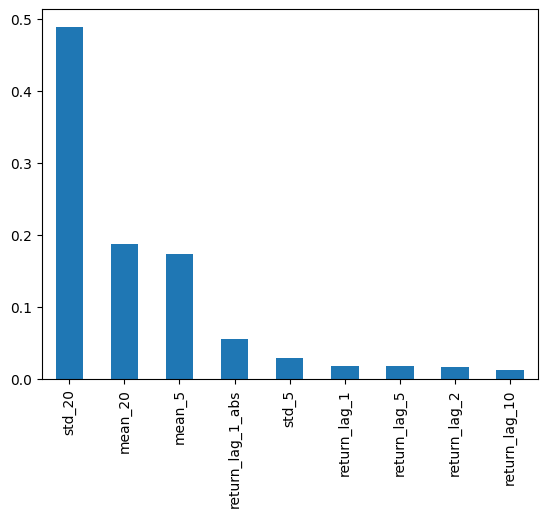

In [38]:
importance = pd.Series(rf_regr.feature_importances_, index=feature_names)
importance.sort_values(ascending=False).plot(kind="bar")

# Conclusions

This project studied short-term volatility prediction in commodity markets using time-series features and machine learning models.

The results show that a simple persistence-based baseline, using recent volatility, already provides strong predictive performance. This confirms the well-known property of volatility clustering: periods of high volatility tend to be followed by high volatility, and vice versa.

Both linear (Ridge) and nonlinear (Random Forest) models achieve modest improvements over the baseline. The improvements are consistent but small, indicating that most of the predictive signal is already captured by past volatility. The Random Forest slightly outperforms the linear model, suggesting the presence of weak nonlinear effects and interactions between features.

Feature importance analysis further supports this interpretation. Long-term volatility (20-day rolling standard deviation) is by far the most influential feature, while short-term volatility and recent trends contribute to a lesser extent. Lagged returns have negligible importance, indicating that return direction does not significantly help predict volatility.

Overall, the findings suggest that volatility dynamics are primarily driven by their own past behavior, with limited additional predictive power from simple machine learning models. While ML methods can capture small nonlinear improvements, they do not fundamentally outperform the persistence-based approach.
